# Data retrieval

In [1]:
# pip install notebook
# pip install ipywidgets

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r'Alcohol_Sales.csv')

In [4]:
df.head()

,DATE,S4248SM144NCEN
0,1992-01-01,3459
1,1992-02-01,3458
2,1992-03-01,4002
3,1992-04-01,4564
4,1992-05-01,4221


In [5]:
df.tail()

,DATE,S4248SM144NCEN
320,2018-09-01,12396
321,2018-10-01,13914
322,2018-11-01,14174
323,2018-12-01,15504
324,2019-01-01,10718


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 325 entries, 0 to 324
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   DATE            325 non-null    object
 1   S4248SM144NCEN  325 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 5.2+ KB


# Data cleaning

In [7]:
# Missing values
df.isna().sum()

DATE              0
S4248SM144NCEN    0
dtype: int64

In [8]:
# Duplicate entries 
df.duplicated().sum()

np.int64(0)

# Data preprocessing

Text(0, 0.5, 'Sales')

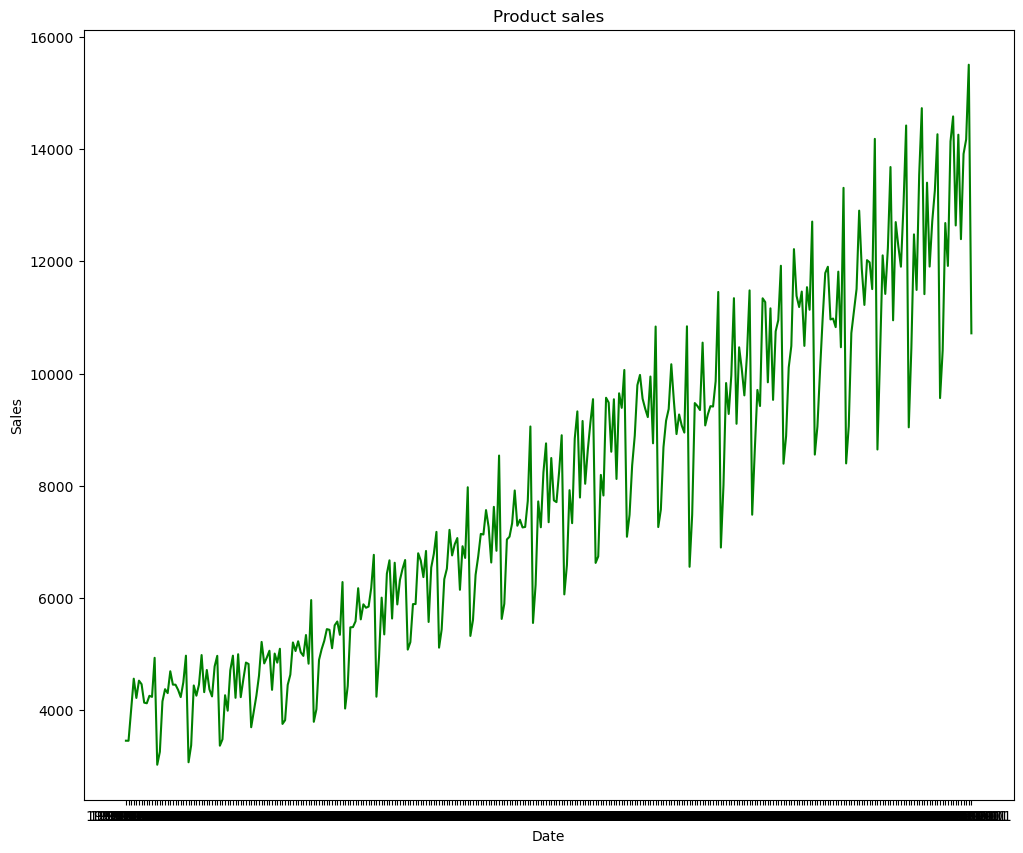

In [9]:
# Check line plot
plt.figure(figsize=(12,10))
sns.lineplot(data=df, x='DATE', y='S4248SM144NCEN', color='green')
plt.title('Product sales')
plt.xlabel('Date')
plt.ylabel('Sales')

In [10]:
df.rename(columns={'DATE':'ds', 'S4248SM144NCEN':'y'}, inplace=True)
df

,ds,y
0,1992-01-01,3459
1,1992-02-01,3458
2,1992-03-01,4002
3,1992-04-01,4564
4,1992-05-01,4221
...,...,...
320,2018-09-01,12396
321,2018-10-01,13914
322,2018-11-01,14174
323,2018-12-01,15504


In [11]:
# Convert ds to a pandas date object
df['ds'] = pd.to_datetime(df['ds'])
df

,ds,y
0,1992-01-01,3459
1,1992-02-01,3458
2,1992-03-01,4002
3,1992-04-01,4564
4,1992-05-01,4221
...,...,...
320,2018-09-01,12396
321,2018-10-01,13914
322,2018-11-01,14174
323,2018-12-01,15504


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 325 entries, 0 to 324
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      325 non-null    datetime64[ns]
 1   y       325 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 5.2 KB


# Data splitting

In [13]:
# Train reps 80% of dataset = 260
train = df.iloc[:260, :]
# Test reps 20% of dataset = 65
test = df.iloc[260:, :]

In [14]:
print(train.shape, test.shape)

(260, 2) (65, 2)


In [15]:
train

,ds,y
0,1992-01-01,3459
1,1992-02-01,3458
2,1992-03-01,4002
3,1992-04-01,4564
4,1992-05-01,4221
...,...,...
255,2013-04-01,10493
256,2013-05-01,12218
257,2013-06-01,11385
258,2013-07-01,11186


In [16]:
test

,ds,y
260,2013-09-01,10494
261,2013-10-01,11540
262,2013-11-01,11138
263,2013-12-01,12709
264,2014-01-01,8557
...,...,...
320,2018-09-01,12396
321,2018-10-01,13914
322,2018-11-01,14174
323,2018-12-01,15504


# Model building

In [17]:
from prophet import Prophet

In [18]:
model = Prophet()
model.fit(train)

15:15:31 - cmdstanpy - INFO - Chain [1] start processing
15:15:32 - cmdstanpy - INFO - Chain [1] done processing


In [19]:
future = test[['ds']]
forecast = model.predict(future)

In [20]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2013-09-01,10680.834411,9972.543729,10984.455954,10680.834411,10680.834411,-172.102635,-172.102635,-172.102635,-172.102635,-172.102635,-172.102635,0.0,0.0,0.0,10508.731776
1,2013-10-01,10710.114795,10421.774480,11357.348248,10710.114795,10710.114795,192.582588,192.582588,192.582588,192.582588,192.582588,192.582588,0.0,0.0,0.0,10902.697383
2,2013-11-01,10740.371192,10474.540057,11431.217437,10740.203933,10740.633975,206.177015,206.177015,206.177015,206.177015,206.177015,206.177015,0.0,0.0,0.0,10946.548207
3,2013-12-01,10769.651575,11304.037355,12325.375761,10769.187155,10770.448301,1079.392510,1079.392510,1079.392510,1079.392510,1079.392510,1079.392510,0.0,0.0,0.0,11849.044085
4,2014-01-01,10799.907972,8737.921251,9740.186700,10798.953388,10801.236125,-1579.881112,-1579.881112,-1579.881112,-1579.881112,-1579.881112,-1579.881112,0.0,0.0,0.0,9220.026860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,2018-09-01,12463.033771,11777.538869,12830.744493,12363.235713,12575.938600,-163.509271,-163.509271,-163.509271,-163.509271,-163.509271,-163.509271,0.0,0.0,0.0,12299.524500
61,2018-10-01,12492.314154,12151.443334,13151.989968,12390.444891,12609.928029,163.288340,163.288340,163.288340,163.288340,163.288340,163.288340,0.0,0.0,0.0,12655.602494
62,2018-11-01,12522.570551,12221.934560,13271.792111,12417.716813,12643.367981,220.894629,220.894629,220.894629,220.894629,220.894629,220.894629,0.0,0.0,0.0,12743.465180
63,2018-12-01,12551.850935,13113.331482,14131.775453,12444.700077,12676.114751,1054.685924,1054.685924,1054.685924,1054.685924,1054.685924,1054.685924,0.0,0.0,0.0,13606.536858


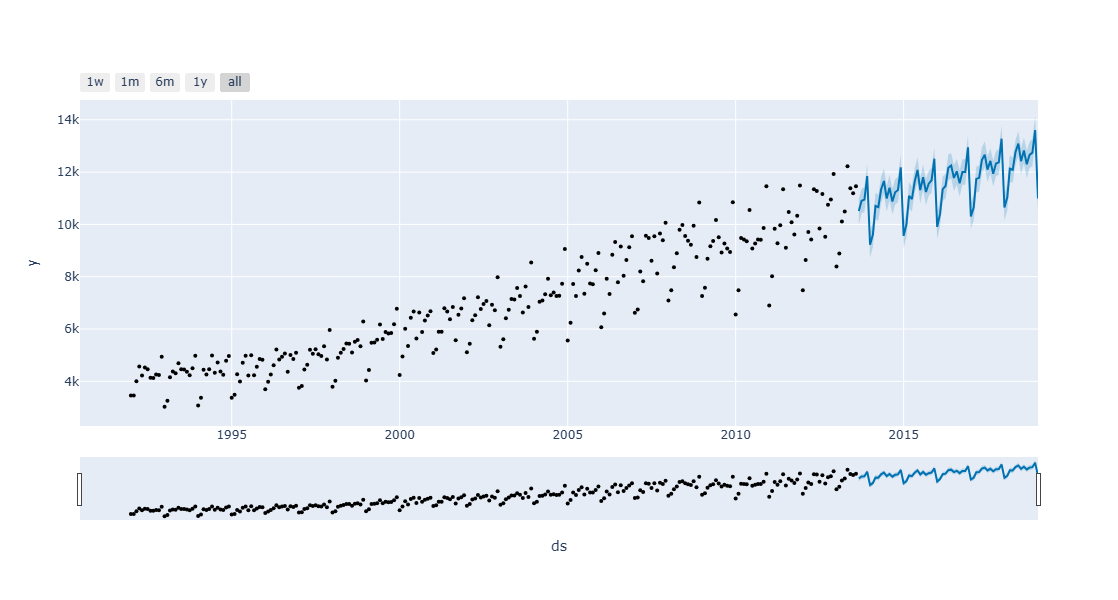

In [21]:
from prophet.plot import plot_plotly

fig = plot_plotly(model, forecast)
fig.show()

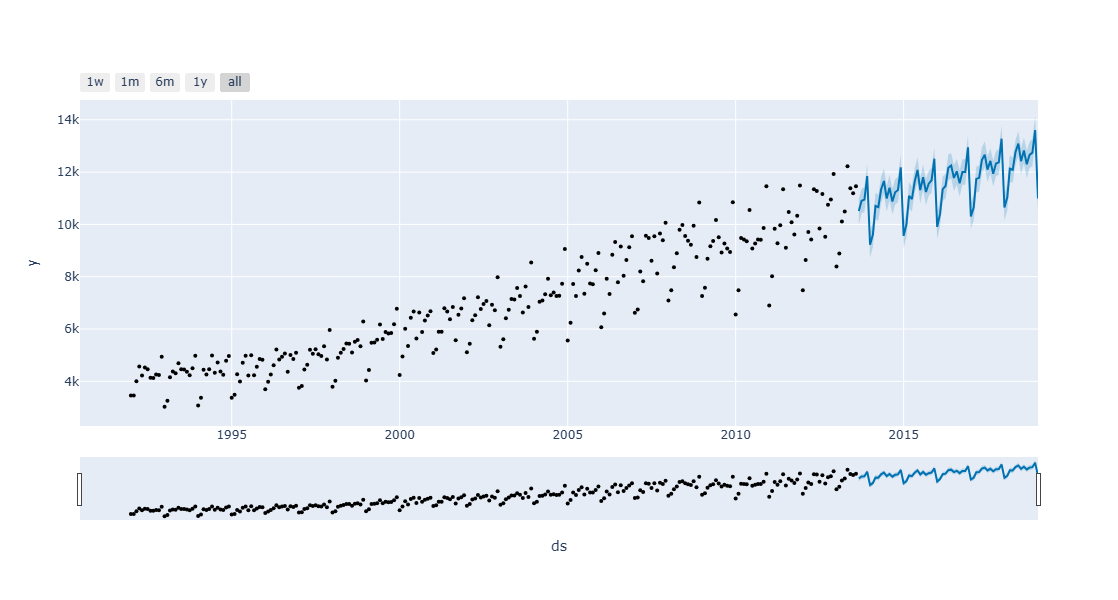

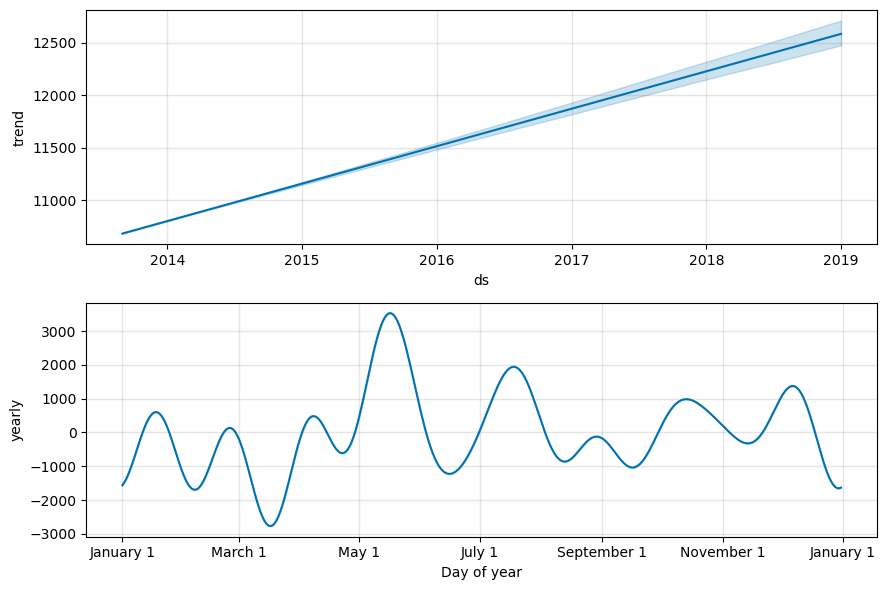

In [22]:
model.plot_components(forecast)
fig.show()

# Performance metrics

In [23]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_squared_error

In [36]:
# Extract y-hat and y from the test data
actual_values = test['y'].reset_index(drop=True)
predicted_values = forecast['yhat'].reset_index(drop=True)
# Store in a df
y = pd.DataFrame({
    'true':actual_values,
    'pred':predicted_values
})
y

,true,pred
0,10494,10508.731776
1,11540,10902.697383
2,11138,10946.548207
3,12709,11849.044085
4,8557,9220.026860
...,...,...
60,12396,12299.524500
61,13914,12655.602494
62,14174,12743.465180
63,15504,13606.536858


In [39]:
def eval_model(y_true, y_pred):
    print(f'\nMAE: {mean_absolute_error(y_true, y_pred)}\n')
    print(f'MSE: {mean_squared_error(y_true, y_pred)}\n')
    print(f'RMSE: {root_mean_squared_error(y_true, y_pred)}\n')

In [40]:
eval_model(y['true'], y['pred'])


MAE: 697.0906386586026

MSE: 740284.6154545962

RMSE: 860.3979401733806

